# Punto 7 — Comparación con otros modelos

Se compara el SARIMA del punto 5 con alternativas más simples. Un modelo complejo resulta útil si mejora las predicciones de referencias sencillas.

- **Media:** predice siempre el promedio del entrenamiento.
- **Último valor:** repite el último dato observado.
- **Ingenuo estacional:** repite la última semana para viajes y los últimos 365 días para temperatura y humedad. En lluvia coincide con el último valor.
- **ARIMA(1,1,1):** usa una diferencia diaria, un término de valores anteriores y otro de errores anteriores.
- **Suavizado exponencial:** da más importancia a datos recientes. Incluye una tendencia que pierde fuerza con el tiempo y una parte semanal aditiva para viajes.

Se conservan las mismas fechas del punto 6: entrenamiento 2023–2024 y prueba 2025. Todas las predicciones parten del 31/12/2024, sin incorporar los datos reales de 2025. Se comparan MAE y RMSE anuales y de los primeros 30 días.

La clasificación por error de prueba describe lo ocurrido en 2025. **No se utiliza para volver a elegir el modelo del punto 5**. Si se tomara una decisión a partir de ella, haría falta otro período independiente para evaluarla.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/bicicletas_rosario.csv').exists())
if str(ROOT/'scripts') not in sys.path: sys.path.insert(0,str(ROOT/'scripts'))
from modelos_puntos56 import cargar, ajustar, ajustados, pronosticar, metricas, etiqueta
from modelos_resto import *
series=cargar(ROOT)
seleccion=json.loads((ROOT/'puntos/punto5/seleccion.json').read_text())
plt.rcParams.update({'figure.figsize':(11,4),'figure.dpi':120})


### Viajes MBTB

,modelo,MAE,RMSE,sesgo
3,Media,417.464,558.325,-1.826
11,Suavizado exponencial,423.706,552.484,173.393
9,"ARIMA(1,1,1)",428.780,559.926,62.139
1,SARIMA punto 5,512.524,635.599,334.702
7,Ingenuo estacional,608.499,811.501,213.085
5,Último valor,931.605,1029.158,864.548


El menor MAE anual corresponde a **Media** (417.46). El SARIMA del punto 5 obtiene 512.52. Esta comparación no demuestra que el ganador sea siempre mejor.

### Temperatura

,modelo,MAE,RMSE,sesgo
13,SARIMA punto 5,3.959,4.926,-0.065
19,Ingenuo estacional,3.968,4.928,-0.047
15,Media,5.981,7.061,-0.509
23,Suavizado exponencial,10.030,11.993,-9.717
17,Último valor,10.102,12.067,-9.798
21,"ARIMA(1,1,1)",10.294,12.260,-10.036


...

,modelo,MAE,RMSE,sesgo
31,Ingenuo estacional,11.011,13.726,0.379
25,SARIMA punto 5,11.474,13.611,3.451
27,Media,11.683,13.984,3.011
33,"ARIMA(1,1,1)",17.582,20.361,15.169
35,Suavizado exponencial,22.573,25.331,21.335
29,Último valor,24.237,26.942,23.225


El menor MAE anual corresponde a **Ingenuo estacional** (11.01). El SARIMA del punto 5 obtiene 11.47. Esta comparación no demuestra que el ganador sea siempre mejor.

### Precipitación

,modelo,MAE,RMSE,sesgo
43,Ingenuo estacional,3.581,10.831,3.302
41,Último valor,3.581,10.831,3.302
37,SARIMA punto 5,4.770,10.350,0.867
39,Media,4.774,10.351,0.863
45,"ARIMA(1,1,1)",4.918,10.334,0.638
47,Suavizado exponencial,5.029,10.326,0.467


El menor MAE anual corresponde a **Ingenuo estacional** (3.58). El SARIMA del punto 5 obtiene 4.77. Esta comparación no demuestra que el ganador sea siempre mejor.

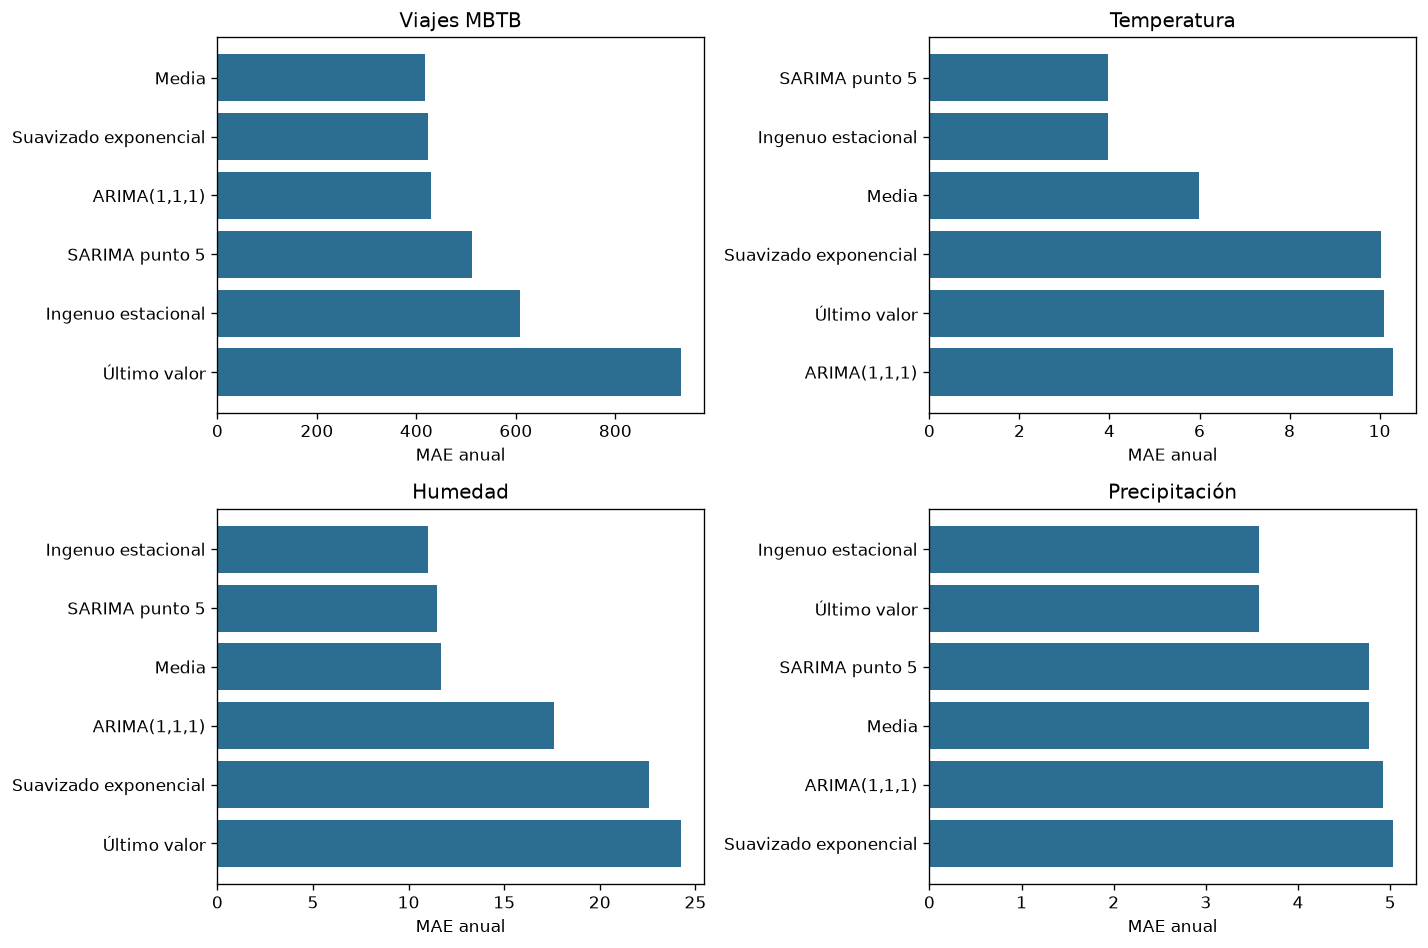

In [2]:
OUT=ROOT/'puntos/punto7'; OUT.mkdir(exist_ok=True)
filas=[]; registros=[]
for nombre,s in series.items():
    train,test=s.loc[:'2024-12-31'],s.loc['2025-01-01':]
    for tipo in ['SARIMA punto 5','Media','Último valor','Ingenuo estacional','ARIMA(1,1,1)','Suavizado exponencial']:
        if tipo=='SARIMA punto 5':
            r,_=ajustar(train,seleccion[nombre]); pred=pronosticar(r,train,seleccion[nombre],test.index)
        else: pred=alternativa(train,test.index,tipo,nombre)
        for h in (30,365):
            filas.append(dict(serie=nombre,modelo=tipo,horizonte=h,**metricas(test.iloc[:h],pred.iloc[:h])))
        registros.append(pd.DataFrame({'fecha':test.index,'serie':nombre,'modelo':tipo,'observado':test.values,'prediccion':pred.values}))
comparacion=pd.DataFrame(filas)
comparacion.to_csv(OUT/'comparacion_modelos.csv',index=False)
pd.concat(registros).to_csv(OUT/'predicciones_modelos.csv',index=False)
for nombre in series:
    tabla=comparacion[(comparacion.serie==nombre)&(comparacion.horizonte==365)].sort_values('MAE')
    display(Markdown(f'### {nombre}'))
    display(tabla[['modelo','MAE','RMSE','sesgo']].round(3))
    mejor=tabla.iloc[0]
    sar=tabla[tabla.modelo=='SARIMA punto 5'].iloc[0]
    display(Markdown(f'El menor MAE anual corresponde a **{mejor.modelo}** ({mejor.MAE:.2f}). '
                     f'El SARIMA del punto 5 obtiene {sar.MAE:.2f}. Esta comparación no demuestra que el ganador sea siempre mejor.'))
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,nombre in zip(axes.flat,series):
    t=comparacion[(comparacion.serie==nombre)&(comparacion.horizonte==365)].sort_values('MAE')
    ax.barh(t.modelo,t.MAE,color='#2c6e91');ax.invert_yaxis();ax.set(title=nombre,xlabel='MAE anual')
fig.tight_layout();fig.savefig(OUT/'comparacion.png');plt.show();plt.close(fig)


## Conclusión

Las referencias simples permiten saber si el SARIMA aporta una mejora real para el período estudiado. Los resultados pueden cambiar con la duración del pronóstico y la época del año. El cuadro de 30 días se conserva en el CSV para esa comparación. En particular, los resultados anuales no representan una operación diaria en la que el modelo recibe observaciones nuevas.

**Herramientas y referencias:** Pandas y NumPy para los datos; Matplotlib para gráficos; statsmodels para los modelos y pruebas. Statsmodels developers. (s. f.). [Documentación de series temporales](https://www.statsmodels.org/stable/tsa.html).